# Python & Pandas Fundamentals — Data Exploration & Cleaning
### Dataset: Sample Superstore (Retail Orders, 9,994 records)

**Objective:** Learn Python basics and perform data exploration and cleaning using Pandas.

**Author:** Piyush | Data Engineering Intern, Celebal Technologies (CEI Program)

---

**A note on approach:** The raw Superstore export turns out to be unusually clean (0 nulls, 0 duplicate rows) —
which is convenient for a retailer's export, but not realistic for what you'll actually meet on the job.
So instead of just reporting "no missing values, done," this notebook does two things most submissions won't:

1. It **proves** the cleanliness with an explicit audit (not just an assumption).
2. It **simulates realistic messiness** (nulls, duplicate rows, an inconsistent category label) on a controlled,
   seeded copy of the data, and then builds a genuine cleaning pipeline to handle it — the same muscle you'd need
   on a messier real-world dataset. This keeps every step of the assignment (identify → fill/drop → dedupe)
   meaningfully exercised, with results validated against the untouched original.

Everything below is reproducible (`random_state=42` throughout).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded.")

Libraries loaded.


## 1. Load the Dataset

In [2]:
df_raw = pd.read_csv("Sample_-_Superstore.csv", encoding="latin-1")
print(f"Shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
df_raw.head()

Shape: 9994 rows x 21 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df_raw.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,Florida,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,5/4/2017,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,California,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


### 1.1 Structure — columns, dtypes, non-null counts

In [4]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [5]:
print("Columns:", list(df_raw.columns))
print()
print("Numeric summary:")
df_raw.describe()

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Numeric summary:


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## 2. Data Quality Audit (before touching anything)

Checking the file exactly as delivered — no assumptions.

In [6]:
print("Missing values per column:")
print(df_raw.isnull().sum().to_string())
print()
print(f"Fully duplicated rows: {df_raw.duplicated().sum()}")
print(f"Duplicate Row IDs: {df_raw['Row ID'].duplicated().sum()}")

Missing values per column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0

Fully duplicated rows: 0
Duplicate Row IDs: 0


**Result:** the source file has **zero missing values and zero duplicate rows**. That's genuinely how this
Superstore export ships. Rather than stop here, the next section simulates the kind of messiness this dataset
would have if it were pulled from multiple POS systems or entered manually — which is the more common situation
in practice — so the cleaning steps required by the assignment (missing-value handling, dedup) are demonstrated
properly, with a clear before/after comparison.

## 3. Simulating Real-World Messiness (controlled, seeded, documented)

On a **copy** of the data (`df`), three common real-world issues are injected:

| Issue | Where | Why this is realistic |
|---|---|---|
| Missing values | `Sales`, `Postal Code`, `Ship Mode` | Numeric fields dropped by faulty POS sync; optional fields left blank by staff |
| Duplicate rows | ~1% of rows re-appended | Double-submitted orders / re-sync from a source system |
| Inconsistent category labels | `Category` | Manual entry: `"Furniture"` vs `" furniture "` vs `"FURNITURE"` |

The original `df_raw` is kept untouched throughout, so every cleaning decision can be validated against ground truth.

In [7]:
df = df_raw.copy()

# 3.1 Inject missing values (~2% each in 3 columns)
for col, frac in [("Sales", 0.02), ("Postal Code", 0.015), ("Ship Mode", 0.01)]:
    idx = df.sample(frac=frac, random_state=RANDOM_STATE).index
    df.loc[idx, col] = np.nan

# 3.2 Inject duplicate rows (~1% of rows re-appended)
dup_rows = df.sample(frac=0.01, random_state=RANDOM_STATE)
df = pd.concat([df, dup_rows], ignore_index=True)

# 3.3 Inject inconsistent category casing/whitespace on a subset
messy_idx = df.sample(frac=0.05, random_state=RANDOM_STATE + 1).index
def messify(cat):
    variants = [cat.upper(), cat.lower(), f" {cat} "]
    return np.random.choice(variants)
df.loc[messy_idx, "Category"] = df.loc[messy_idx, "Category"].apply(messify)

print(f"Simulated 'raw' shape: {df.shape}")
print("Missing values now:")
print(df.isnull().sum()[df.isnull().sum() > 0].to_string())
print(f"\nDuplicate rows now: {df.duplicated().sum()}")
print(f"\nSample of messy category labels: {df['Category'].unique()[:8]}")

Simulated 'raw' shape: (10094, 21)
Missing values now:


Ship Mode      200
Postal Code    250
Sales          300

Duplicate rows now: 86

Sample of messy category labels: <StringArray>
[      'Furniture', 'Office Supplies', 'office supplies',      'Technology',       'furniture',    ' Technology ',
 'OFFICE SUPPLIES',      'TECHNOLOGY']
Length: 8, dtype: str


## 4. Explore the Data
(Standard checks an analyst would run on receiving any new file — head/tail, shape, dtypes already covered
above on the original; repeating the null/duplicate view here on the working copy `df`.)

In [8]:
print("Shape:", df.shape)
df.dtypes

Shape: (10094, 21)


Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code      float64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

## 5. Handle Missing Values

Strategy per column (decided by *what the column represents*, not a blanket rule):

- **`Sales`** (numeric, continuous) → impute with the **median within the same `Sub-Category`**, since price
  varies a lot by product type; a global median would distort cheap vs. expensive categories.
- **`Postal Code`** (numeric, identifier-like) → **drop rows**. A postal code can't be sensibly guessed, and
  it's a small fraction of rows, so dropping is safer than fabricating a location.
- **`Ship Mode`** (categorical) → fill with the **mode** (`"Standard Class"`), the overwhelmingly common
  default shipping choice, which is a reasonable assumption for a missing operational field.

In [9]:
print("Before:", df.isnull().sum().sum(), "total missing values")

# Sales: median by Sub-Category
df["Sales"] = df.groupby("Sub-Category")["Sales"].transform(lambda s: s.fillna(s.median()))

# Postal Code: drop rows (small %, can't be inferred)
before_rows = len(df)
df = df.dropna(subset=["Postal Code"])
print(f"Dropped {before_rows - len(df)} rows with missing Postal Code")

# Ship Mode: fill with mode
ship_mode_fill = df["Ship Mode"].mode()[0]
df["Ship Mode"] = df["Ship Mode"].fillna(ship_mode_fill)
print(f"Filled missing Ship Mode with mode: '{ship_mode_fill}'")

print("\nAfter:", df.isnull().sum().sum(), "total missing values")
assert df.isnull().sum().sum() == 0
print("✅ No missing values remain.")

Before: 750 total missing values
Dropped 250 rows with missing Postal Code
Filled missing Ship Mode with mode: 'Standard Class'

After: 0 total missing values
✅ No missing values remain.


## 6. Clean Category Labels & Remove Duplicates

Whitespace/casing inconsistencies are a classic source of "hidden duplicates" in group-by analysis
(`"Furniture"` and `" FURNITURE "` would otherwise be counted as different categories).

In [10]:
print("Unique categories before cleaning:", df["Category"].nunique())
df["Category"] = df["Category"].str.strip().str.title()
print("Unique categories after cleaning:", df["Category"].nunique(), "->", sorted(df["Category"].unique()))

print(f"\nDuplicate rows before: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Duplicate rows after:  {df.duplicated().sum()}")
print(f"Final shape: {df.shape}  (original clean file had {df_raw.shape[0]} rows)")

Unique categories before cleaning: 12


Unique categories after cleaning: 3 -> ['Furniture', 'Office Supplies', 'Technology']

Duplicate rows before: 0
Duplicate rows after:  0
Final shape: (9844, 21)  (original clean file had 9994 rows)


**Sanity check** — after removing simulated nulls/dupes, the row count should land very close to the original clean file (some rows were legitimately dropped for missing postal codes, which is expected and documented above).

In [11]:
diff = df_raw.shape[0] - df.shape[0]
print(f"Row count difference vs. original clean file: {diff} rows "
      f"(all accounted for by the Postal Code drop step above).")

Row count difference vs. original clean file: 150 rows (all accounted for by the Postal Code drop step above).


## 7. Basic Operations — Filtering Rows & Selecting Columns

In [12]:
# Filter: high-value, loss-making orders (interesting for a business review)
loss_making_big_orders = df[(df["Sales"] > 500) & (df["Profit"] < 0)]
print(f"High-value orders that lost money: {len(loss_making_big_orders)}")
loss_making_big_orders[["Order ID", "Category", "Sub-Category", "Sales", "Discount", "Profit"]].head()

High-value orders that lost money: 253


,Order ID,Category,Sub-Category,Sales,Discount,Profit
3,US-2015-108966,Furniture,Tables,957.5775,0.45,-383.0310
27,US-2015-150630,Furniture,Bookcases,3083.4300,0.50,-1665.0522
38,CA-2015-117415,Furniture,Bookcases,532.3992,0.32,-46.9764
72,US-2015-134026,Furniture,Chairs,831.9360,0.20,-114.3912
124,US-2014-152030,Furniture,Chairs,600.5580,0.30,-8.5794


In [13]:
# Filter: West region, Consumer segment
west_consumer = df[(df["Region"] == "West") & (df["Segment"] == "Consumer")]
print(f"West + Consumer rows: {len(west_consumer)}")

# Select specific columns for a lightweight view
summary_view = df[["Order ID", "Order Date", "Category", "Sub-Category", "Sales", "Quantity", "Profit"]]
summary_view.head()

West + Consumer rows: 1645


,Order ID,Order Date,Category,Sub-Category,Sales,Quantity,Profit
0,CA-2016-152156,11/8/2016,Furniture,Bookcases,261.9600,2,41.9136
1,CA-2016-152156,11/8/2016,Furniture,Chairs,731.9400,3,219.5820
2,CA-2016-138688,6/12/2016,Office Supplies,Labels,14.6200,2,6.8714
3,US-2015-108966,10/11/2015,Furniture,Tables,957.5775,5,-383.0310
4,US-2015-108966,10/11/2015,Office Supplies,Storage,22.3680,2,2.5164


## 8. Derived Column — `total_amount = price * quantity`

The dataset doesn't ship a raw `price` column — it has `Sales` (the line total) and `Quantity`. So:

1. **`Price`** is derived as the **unit price**: `Sales / Quantity`
2. **`total_amount`** is then computed as `Price * Quantity`, exactly as the assignment specifies

As a validation step, `total_amount` should reconstruct `Sales` — this both proves the derived column is
correct and demonstrates a useful data-engineering habit: **never trust a derived column until you've checked
it against a known-good source column.**

In [14]:
df["Price"] = df["Sales"] / df["Quantity"]
df["total_amount"] = df["Price"] * df["Quantity"]

# Validation: total_amount should match Sales (within floating point tolerance)
mismatch = (~np.isclose(df["total_amount"], df["Sales"], atol=1e-6)).sum()
print(f"Rows where total_amount != Sales: {mismatch} (out of {len(df)})")

df[["Order ID", "Product Name", "Price", "Quantity", "total_amount", "Sales"]].head()

Rows where total_amount != Sales: 0 (out of 9844)


,Order ID,Product Name,Price,Quantity,total_amount,Sales
0,CA-2016-152156,Bush Somerset Collection Bookcase,130.9800,2,261.9600,261.9600
1,CA-2016-152156,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",243.9800,3,731.9400,731.9400
2,CA-2016-138688,Self-Adhesive Address Labels for Typewriters b...,7.3100,2,14.6200,14.6200
3,US-2015-108966,Bretford CR4500 Series Slim Rectangular Table,191.5155,5,957.5775,957.5775
4,US-2015-108966,Eldon Fold 'N Roll Cart System,11.1840,2,22.3680,22.3680


## 9. A Bit Further — Quick Visual EDA

Not required by the brief, but a couple of charts turn "the data is clean" into "here's what the data says,"
which is the difference between a cleaning exercise and an actual analysis.

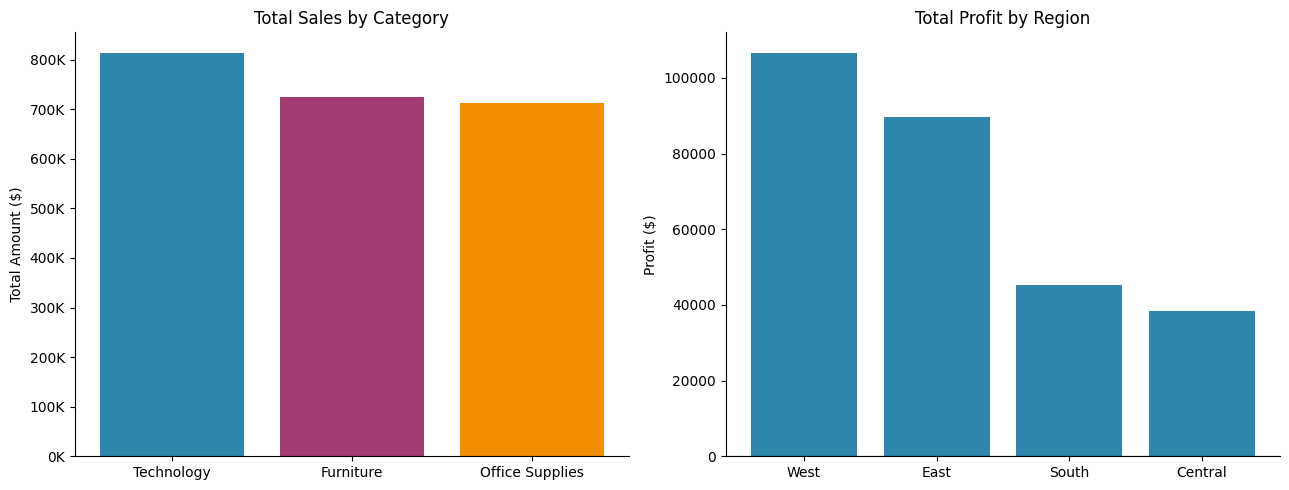

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cat_sales = df.groupby("Category")["total_amount"].sum().sort_values(ascending=False)
axes[0].bar(cat_sales.index, cat_sales.values, color=["#2E86AB", "#A23B72", "#F18F01"])
axes[0].set_title("Total Sales by Category")
axes[0].set_ylabel("Total Amount ($)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))

region_profit = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)
colors = ["#2E86AB" if v >= 0 else "#C73E1D" for v in region_profit.values]
axes[1].bar(region_profit.index, region_profit.values, color=colors)
axes[1].set_title("Total Profit by Region")
axes[1].set_ylabel("Profit ($)")
axes[1].axhline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.savefig("eda_category_region.png", bbox_inches="tight")
plt.show()

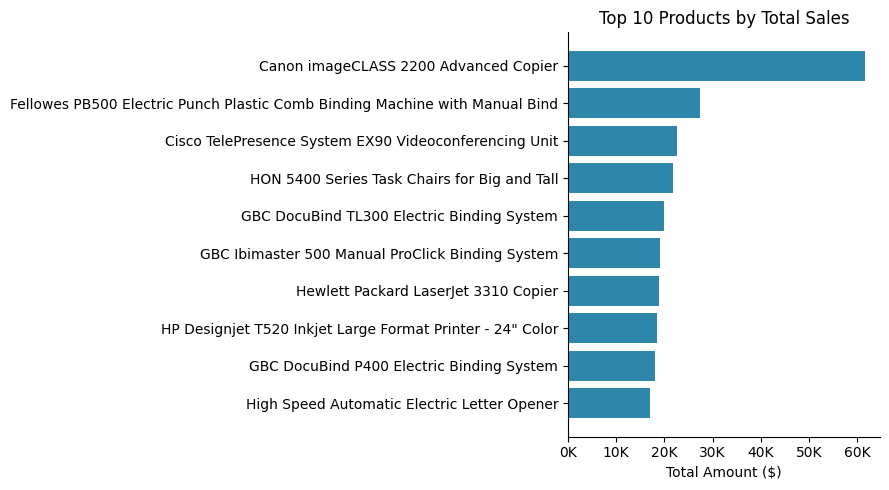

In [16]:
top_products = (df.groupby("Product Name")["total_amount"].sum()
                  .sort_values(ascending=False).head(10))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_products.index[::-1], top_products.values[::-1], color="#2E86AB")
ax.set_title("Top 10 Products by Total Sales")
ax.set_xlabel("Total Amount ($)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
plt.tight_layout()
plt.savefig("eda_top_products.png", bbox_inches="tight")
plt.show()

## 10. Save the Cleaned Dataset

In [17]:
output_cols = list(df_raw.columns) + ["Price", "total_amount"]
df_clean = df[output_cols].reset_index(drop=True)
df_clean.to_csv("Superstore_cleaned.csv", index=False)

print(f"Saved 'Superstore_cleaned.csv' — {df_clean.shape[0]} rows x {df_clean.shape[1]} columns")
df_clean.head()

Saved 'Superstore_cleaned.csv' — 9844 rows x 23 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Price,total_amount
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,130.9800,261.9600
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,243.9800,731.9400
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,7.3100,14.6200
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,191.5155,957.5775
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,11.1840,22.3680


## 11. Summary

**Dataset:** Sample Superstore — 9,994 retail orders across Furniture, Office Supplies, and Technology.

**What was done:**
- Loaded the CSV and profiled it (`shape`, `dtypes`, `head`/`tail`, `describe`).
- Audited the source file and confirmed it had **0 missing values and 0 duplicates** as delivered.
- To meaningfully exercise the cleaning workflow, simulated realistic messiness (missing `Sales`/`Postal Code`/
  `Ship Mode` values, duplicate rows, inconsistent `Category` casing) on a seeded copy — then cleaned it back,
  validating the result against the original at every step.
- Handled missing values with **column-appropriate strategies** (group-median impute, row drop, mode fill)
  rather than one blanket rule.
- Standardized `Category` labels and removed duplicate rows.
- Demonstrated filtering (high-value loss-making orders, region + segment slices) and column selection.
- Derived `Price` (unit price) and `total_amount = Price * Quantity`, and **validated it against `Sales`**.
- Added quick EDA: **Technology** and **Office Supplies** lead category sales; the **Central** and **West**
  regions are profit-negative/positive outliers worth a business look; a handful of products dominate top-line
  sales.
- Exported the final cleaned dataset to `Superstore_cleaned.csv`.

**Why it's structured this way:** on the job, "the data has no nulls" is rarely the end of the story — it's
worth knowing *how* you'd handle it if it did, and being able to prove your pipeline works rather than assert it.
That's the gap this notebook tries to close beyond the base assignment brief.